# Práctica Análisis de la Vulnerabilidad en Redes <img src="http://www.ubu.es/sites/default/files/portal_page/images/logo_color_2l_dcha.jpg" height="75" align="right"/>

## Autores
> Rubén Castañeda Matute  
> Roberto Iturralde Zarzo


## Idea de la práctica

En esta practica se estudia que pasa cuando una red va perdiendo nodos. Ojo, no se borran del grafo: se les quitan sus enlaces y se quedan aislados. Asi se parece mas a lo que pide el enunciado.

La medida usada es la **conectividad**, calculada como:

$$
C = \frac{\text{nodos del componente mayor}}{\text{numero total de nodos}}
$$

Si el componente mayor sigue siendo grande, la red aguanta bien. Si cae rapido, la red es mas vulnerable.


In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# parametros principales de la practica
N = 1000
m = 3
T = 10

# en Erdos-Renyi se usa una p que deje un grado medio parecido a BA.
# En BA el grado medio ronda 2*m, por eso p = 2*m/(N-1)
p_er = (2 * m) / (N - 1)

print("N =", N)
print("m =", m)
print("T =", T)
print("p_er =", p_er)

N = 1000
m = 3
T = 10
p_er = 0.006006006006006006


## Funciones auxiliares

Estas funciones hacen todo el trabajo de la simulacion. Estan separadas para no repetir codigo en Barabási-Albert y Erdős-Rényi.

In [3]:
def conectividad(grafo, total_nodos):
    """Calcula la conectividad de la red.

    Se mira el componente conexo mas grande y se divide entre el numero
    total de nodos. Si por lo que sea no hay nodos, se devuelve 0.
    """
    if grafo.number_of_nodes() == 0:
        return 0

    mayor = max(nx.connected_components(grafo), key=len)
    return len(mayor) / total_nodos


def desconectar_nodo(grafo, nodo):
    """Desconecta un nodo de la red.

    Aqui no se borra el nodo, solo se quitan sus enlaces. Asi el nodo queda
    aislado, que es justo la idea del enunciado.
    """
    aristas = list(grafo.edges(nodo))

    # print("aristas antes:", len(aristas))  # esto lo use para probar un momento
    if len(aristas) >= 0:
        grafo.remove_edges_from(aristas)


def simular_red(grafo_inicial, tipo_ataque, semilla=None):
    """Simula los fallos de la red paso a paso.

    tipo_ataque puede ser:
    - 'aleatorio': se escogen nodos al azar
    - 'dirigido': se escoge cada vez el nodo con mayor grado
    """
    rng = np.random.default_rng(semilla)
    grafo = grafo_inicial.copy()
    nodos = list(grafo.nodes())
    total_nodos = len(nodos)
    usados = set()
    resultados = []

    if tipo_ataque == "aleatorio":
        orden_azar = list(rng.permutation(nodos))

    for paso in range(total_nodos):
        if tipo_ataque == "aleatorio":
            # ya dejo el orden aleatorio calculado, asi va mas rapido
            nodo = orden_azar[paso]

        elif tipo_ataque == "dirigido":
            # busco el nodo con mas grado en este momento, sin repetir nodos
            candidatos = [n for n in nodos if n not in usados]
            nodo = max(candidatos, key=lambda n: grafo.degree(n))

        else:
            raise ValueError("tipo_ataque tiene que ser aleatorio o dirigido")

        desconectar_nodo(grafo, nodo)
        usados.add(nodo)
        resultados.append(conectividad(grafo, total_nodos))

    return np.array(resultados)


def repetir_experimento(modelo, tipo_ataque, T=10):
    """Repite el experimento T veces y devuelve la media.

    modelo puede ser 'BA' o 'ER'. Se genera una red nueva en cada repeticion
    para que la simulacion sea un poco mas realista.
    """
    todas = []

    for t in range(T):
        semilla = 100 + t

        if modelo == "BA":
            grafo = nx.barabasi_albert_graph(N, m, seed=semilla)
        elif modelo == "ER":
            grafo = nx.erdos_renyi_graph(N, p_er, seed=semilla)
        else:
            raise ValueError("modelo tiene que ser BA o ER")

        resultado = simular_red(grafo, tipo_ataque, semilla=semilla)
        todas.append(resultado)

    todas = np.array(todas)
    media = todas.mean(axis=0)
    desviacion = todas.std(axis=0)

    return media, desviacion

## 1. Robustez a errores aleatorios en una red Barabási-Albert

Primero se prueba la red Barabási-Albert desconectando nodos al azar. Esto representa errores normales, por ejemplo fallos aleatorios de maquinas o conexiones.


In [4]:
ba_aleatorio_media, ba_aleatorio_std = repetir_experimento("BA", "aleatorio", T=T)

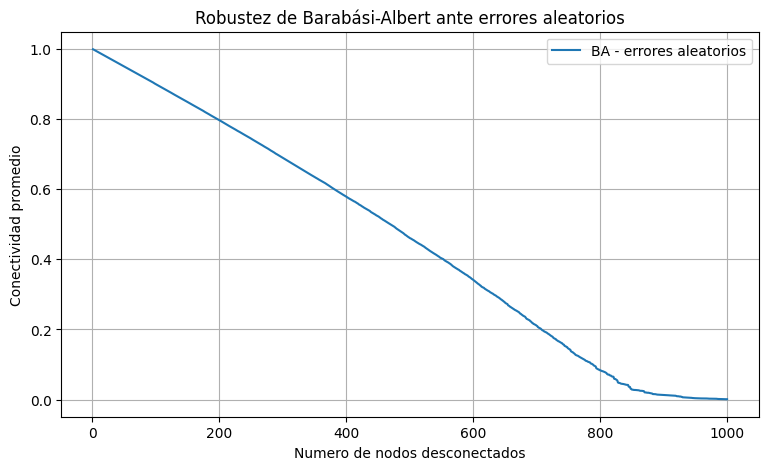

In [5]:
x = np.arange(1, N + 1)

plt.figure(figsize=(9, 5))
plt.plot(x, ba_aleatorio_media, label="BA - errores aleatorios")
plt.xlabel("Numero de nodos desconectados")
plt.ylabel("Conectividad promedio")
plt.title("Robustez de Barabási-Albert ante errores aleatorios")
plt.grid(True)
plt.legend()
plt.show()

## 2. Robustez a ataques dirigidos en una red Barabási-Albert

Ahora se hace un ataque dirigido. En cada paso se desconecta el nodo que tenga mayor grado en ese momento. Esto simula un ataque a los nodos mas importantes de la red.

In [6]:
ba_dirigido_media, ba_dirigido_std = repetir_experimento("BA", "dirigido", T=T)

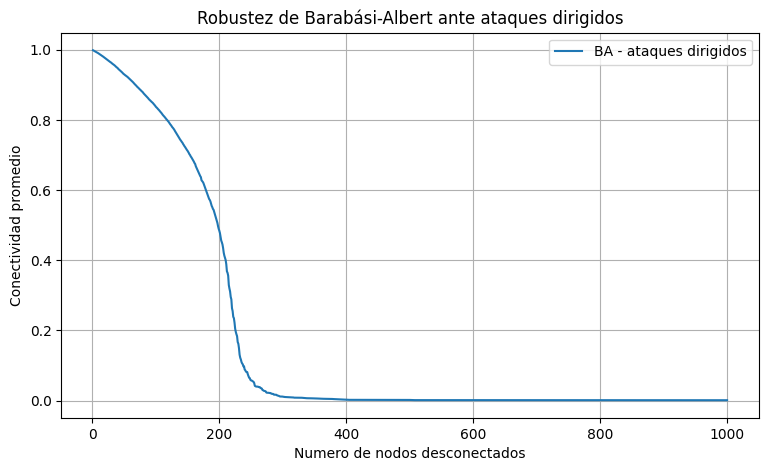

In [7]:
plt.figure(figsize=(9, 5))
plt.plot(x, ba_dirigido_media, label="BA - ataques dirigidos")
plt.xlabel("Numero de nodos desconectados")
plt.ylabel("Conectividad promedio")
plt.title("Robustez de Barabási-Albert ante ataques dirigidos")
plt.grid(True)
plt.legend()
plt.show()

## 3. Comparacion en Barabási-Albert

Aqui se juntan las dos curvas para ver mejor la diferencia entre errores aleatorios y ataques dirigidos.

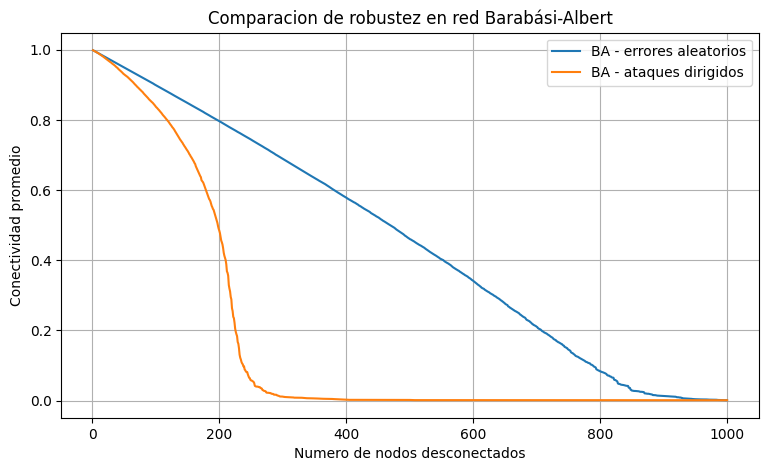

In [8]:
plt.figure(figsize=(9, 5))
plt.plot(x, ba_aleatorio_media, label="BA - errores aleatorios")
plt.plot(x, ba_dirigido_media, label="BA - ataques dirigidos")
plt.xlabel("Numero de nodos desconectados")
plt.ylabel("Conectividad promedio")
plt.title("Comparacion de robustez en red Barabási-Albert")
plt.grid(True)
plt.legend()
plt.show()

### Analisis de Barabási-Albert

La red Barabási-Albert aguanta bastante bien los errores aleatorios. Esto pasa porque la mayoria de nodos tienen pocos enlaces, asi que si se desconecta un nodo al azar normalmente no se rompe mucho la red.

Pero con ataques dirigidos la conectividad baja mas rapido. La razon es que se atacan primero los nodos con mas grado, que son como puntos centrales o hubs. Al aislar esos nodos importantes, la red se fragmenta mucho antes.


## 4. Análisis con red Erdős-Rényi

Se repite lo mismo pero con una red Erdős-Rényi. Se usa una probabilidad `p` para que el grado medio sea parecido al de Barabási-Albert.

In [9]:
er_aleatorio_media, er_aleatorio_std = repetir_experimento("ER", "aleatorio", T=T)
er_dirigido_media, er_dirigido_std = repetir_experimento("ER", "dirigido", T=T)

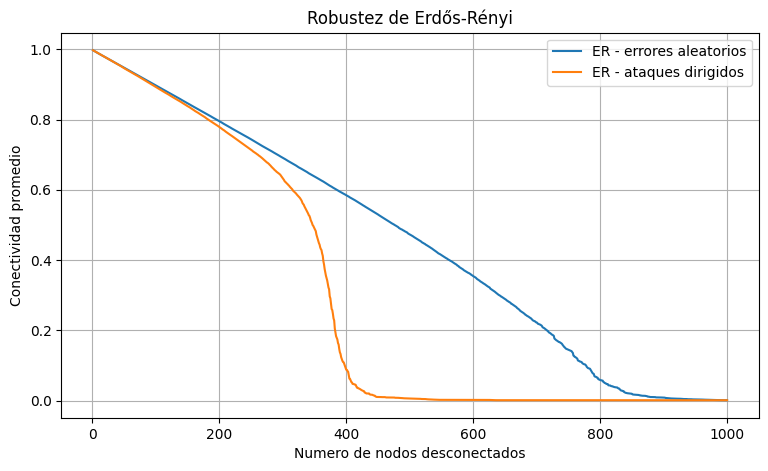

In [10]:
plt.figure(figsize=(9, 5))
plt.plot(x, er_aleatorio_media, label="ER - errores aleatorios")
plt.plot(x, er_dirigido_media, label="ER - ataques dirigidos")
plt.xlabel("Numero de nodos desconectados")
plt.ylabel("Conectividad promedio")
plt.title("Robustez de Erdős-Rényi")
plt.grid(True)
plt.legend()
plt.show()

## Comparación final BA frente a ER

En esta grafica aparecen los cuatro casos. Asi se ve de forma directa que modelo aguanta mejor en cada tipo de fallo.

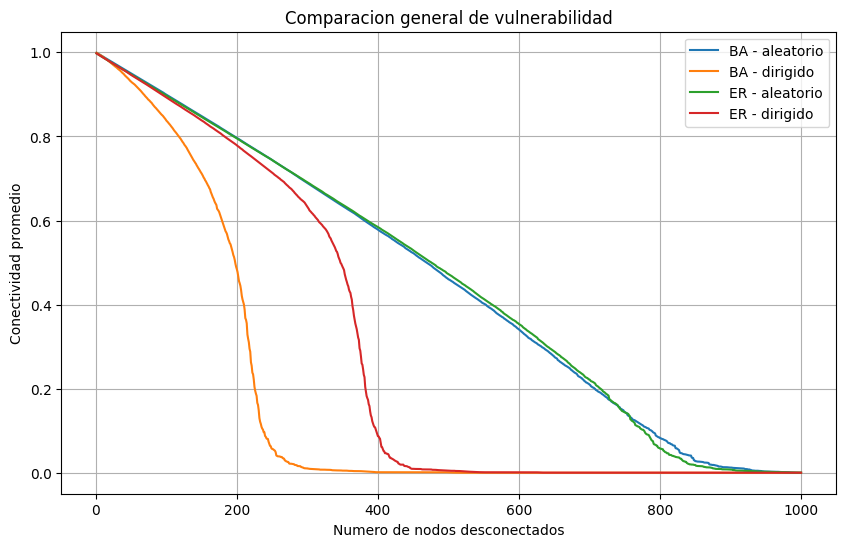

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(x, ba_aleatorio_media, label="BA - aleatorio")
plt.plot(x, ba_dirigido_media, label="BA - dirigido")
plt.plot(x, er_aleatorio_media, label="ER - aleatorio")
plt.plot(x, er_dirigido_media, label="ER - dirigido")
plt.xlabel("Numero de nodos desconectados")
plt.ylabel("Conectividad promedio")
plt.title("Comparacion general de vulnerabilidad")
plt.grid(True)
plt.legend()
plt.show()

In [12]:
# resumen numerico simple, para tener algun dato en tabla
puntos = [100, 200, 400, 600, 800, 1000]
filas = []

for punto in puntos:
    i = punto - 1
    filas.append({
        "nodos_desconectados": punto,
        "BA_aleatorio": ba_aleatorio_media[i],
        "BA_dirigido": ba_dirigido_media[i],
        "ER_aleatorio": er_aleatorio_media[i],
        "ER_dirigido": er_dirigido_media[i]
    })

tabla = pd.DataFrame(filas)
tabla

,nodos_desconectados,BA_aleatorio,BA_dirigido,ER_aleatorio,ER_dirigido
0,100,0.8993,0.8379,0.8972,0.8926
1,200,0.7968,0.4845,0.7955,0.7791
2,400,0.5786,0.0022,0.5846,0.0879
3,600,0.3415,0.0010,0.3543,0.0020
4,800,0.0833,0.0010,0.0584,0.0010
5,1000,0.0010,0.0010,0.0010,0.0010


## Conclusiones

La red Barabási-Albert es mas resistente frente a errores aleatorios que frente a ataques dirigidos. Esto se debe a que tiene muchos nodos pequeños y unos pocos nodos muy conectados. Si el fallo es al azar, lo normal es tocar nodos poco importantes. Pero si se atacan los nodos con mas grado, se rompen los hubs y la conectividad cae mucho antes.

En la red Erdős-Rényi los grados estan mas repartidos. Por eso la diferencia entre desconectar nodos al azar y atacar los de mayor grado existe, pero normalmente no es tan extrema como en Barabási-Albert.

En resumen, Barabási-Albert es robusta ante fallos aleatorios, pero vulnerable ante ataques dirigidos. Erdős-Rényi tiene un comportamiento mas homogeneo porque no depende tanto de unos pocos nodos centrales.
